In [1]:
import requests
from bs4 import BeautifulSoup

# Import pandas
import pandas as pd

#Import numpy
import numpy as np

# Import stopwords
import nltk
from nltk.corpus import stopwords

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zschaudhry\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\zschaudhry\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\zschaudhry\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
# Execute request
# If you’re using a different site just replace the url e.g. r=requests.get(‘put your url in here’)
r = requests.get('https://www.yelp.com/biz/namakmandi-shinwari-grill-falls-church-2?osq=Shinwari+Namak+Mandi')


In [4]:
# Check request status
print(r.status_code)

200


In [5]:
# Check result
#r.text

In [6]:
# Make the soup
soup = BeautifulSoup(r.text, 'html.parser')
# First get all of the review-content divs    
results = soup.findAll(class_='comment__09f24__D0cxf')


In [7]:
# Loop through review-content divs and extract paragraph text
reviews = []
for result in results:
  reviews.append(result.text)

In [8]:
for review in reviews:
    print(review, "\n")

I went to Namak Mandi upon my friend's suggestion who had been there couple of times. We found parking at the back of the building easily. Entering into the restaurant it gives a total desi kind of vibes, it's quite large space and looks pretty kool. We were party of four ladies and were seated promptly by very sweet lady server. We ordered Chapli kebab, nihari, chicken boneless kebabs, Mandi with chicken and Lahori fish. Luckily all our meals came out in a very reasonable amount of time and everything was freshly made and steaming hot. I must say everything that we ordered was tasted great nothing that I can find have any issue. Service was reasonable too. Since it was a Saturday night, restaurant was full and there was only one lady server and one buss boy, to me this needs to be better. We lastly ordered some doodh Patti and it was delicious too.Overall we had a great experience and I do recommend this place. 

Although I had to wait extra 30 mins for the order to be ready when I we

In [9]:
# Create a pandas dataframe from array
df = pd.DataFrame(np.array(reviews), columns=['review'])

In [10]:
# Calculate word count
df['word_count'] = df['review'].apply(lambda x: len(str(x).split(" ")))

In [11]:
# Calculate character count
df['char_count'] = df['review'].str.len()

In [12]:
def avg_word(review):
  words = review.split()
  return (sum(len(word) for word in words) / len(words))

# Calculate average words
df['avg_word'] = df['review'].apply(lambda x: avg_word(x))

In [13]:

stop_words = stopwords.words('english')
df['stopword_coun'] = df['review'].apply(lambda x: len([x for x in x.split() if x in stop_words]))

In [14]:
df.describe()

,word_count,char_count,avg_word,stopword_coun
count,10.000000,10.000000,10.000000,10.000000
mean,54.500000,318.200000,5.132785,19.200000
std,53.899598,298.632364,0.624920,24.921209
min,18.000000,103.000000,4.071429,3.000000
25%,26.000000,156.000000,4.787559,6.000000
50%,27.500000,182.000000,5.038462,7.500000
75%,44.250000,269.000000,5.594686,14.250000
max,167.000000,925.000000,6.000000,68.000000


In [15]:
df.head()

,review,word_count,char_count,avg_word,stopword_coun
0,I went to Namak Mandi upon my friend's suggest...,167,925,4.544910,68
1,Although I had to wait extra 30 mins for the o...,42,212,4.071429,16
2,Fresh naan and amazing kabobs! 10/10 my husban...,18,103,4.777778,5
3,Was not expecting such too class food quality....,143,826,4.816901,64
4,Great Food. Three id us visiting for long time...,23,152,5.652174,3


In [16]:
df.tail()

,review,word_count,char_count,avg_word,stopword_coun
5,Planned a fever order at 2PM. It's 3:37 and we...,26,156,5.038462,6
6,Out class food and service.We went from Baltim...,29,201,5.965517,8
7,"Tried this restaurant, saw good reviews of thi...",45,288,5.422222,6
8,Stop here without much expectation as I was go...,26,156,5.038462,7
9,I have tried twice this place and both time ve...,26,163,6.000000,9


In [17]:
# Lower case all words
df['review_lower'] = df['review'].apply(lambda x: " ".join(x.lower() for x in x.split()))

In [18]:
# Remove Punctuation
df['review_nopunc'] = df['review_lower'].str.replace('[^\w\s]', '')

In [19]:
# Remove Stopwords
df['review_nopunc_nostop'] = df['review_nopunc'].apply(lambda x: " ".join(x for x in x.split() if x not in stop_words))

In [20]:
# Return frequency of values
freq= pd.Series(" ".join(df['review_nopunc_nostop']).split()).value_counts()[:30]

In [21]:
freq.head()

food       8
good       5
ordered    5
great      4
service    4
Name: count, dtype: int64

In [22]:
#print(freq)

Based on words that you’re seeing, you can create a list of those that aren’t adding much meaning. In this case, there are a few that are probably worth removing, these can be added to a new stopwords list.

In [23]:
other_stopwords = ['get', 'us', 'see', 'use', 'said', 'asked', 'day', 'go' \
  'even', 'ive', 'right', 'left', 'always', 'would', 'told', \
  'get', 'us', 'would', 'get', 'one', 'ive', 'go', 'even', \
  'also', 'ever', 'x', 'take', 'let' ]

In [24]:
df['review_nopunc_nostop_nocommon'] = df['review_nopunc_nostop'].apply(lambda x: "".join(" ".join(x for x in x.split() if x not in other_stopwords)))

In [25]:
df.head()

,review,word_count,char_count,avg_word,stopword_coun,review_lower,review_nopunc,review_nopunc_nostop,review_nopunc_nostop_nocommon
0,I went to Namak Mandi upon my friend's suggest...,167,925,4.544910,68,i went to namak mandi upon my friend's suggest...,i went to namak mandi upon my friend's suggest...,went namak mandi upon friend's suggestion coup...,went namak mandi upon friend's suggestion coup...
1,Although I had to wait extra 30 mins for the o...,42,212,4.071429,16,although i had to wait extra 30 mins for the o...,although i had to wait extra 30 mins for the o...,although wait extra 30 mins order ready went p...,although wait extra 30 mins order ready went p...
2,Fresh naan and amazing kabobs! 10/10 my husban...,18,103,4.777778,5,fresh naan and amazing kabobs! 10/10 my husban...,fresh naan and amazing kabobs! 10/10 my husban...,fresh naan amazing kabobs! 10/10 husband loved...,fresh naan amazing kabobs! 10/10 husband loved...
3,Was not expecting such too class food quality....,143,826,4.816901,64,was not expecting such too class food quality....,was not expecting such too class food quality....,expecting class food quality. place hands one ...,expecting class food quality. place hands best...
4,Great Food. Three id us visiting for long time...,23,152,5.652174,3,great food. three id us visiting for long time...,great food. three id us visiting for long time...,great food. three id us visiting long time reu...,great food. three id visiting long time reunio...


In [26]:
from textblob import Word
# Lemmatize final review format
df['cleaned_review'] = df['review_nopunc_nostop_nocommon']\
.apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

ModuleNotFoundError: No module named 'textblob'

In [27]:
# Calculate polarity
from textblob import TextBlob
df['polarity'] = df['cleaned_review'].apply(lambda x: TextBlob(x).sentiment[0])

ModuleNotFoundError: No module named 'textblob'

In [28]:
df[['review', 'polarity']]

KeyError: "['polarity'] not in index"

In [29]:
df.describe()

,word_count,char_count,avg_word,stopword_coun
count,10.000000,10.000000,10.000000,10.000000
mean,54.500000,318.200000,5.132785,19.200000
std,53.899598,298.632364,0.624920,24.921209
min,18.000000,103.000000,4.071429,3.000000
25%,26.000000,156.000000,4.787559,6.000000
50%,27.500000,182.000000,5.038462,7.500000
75%,44.250000,269.000000,5.594686,14.250000
max,167.000000,925.000000,6.000000,68.000000


In [30]:
df.head(3)

,review,word_count,char_count,avg_word,stopword_coun,review_lower,review_nopunc,review_nopunc_nostop,review_nopunc_nostop_nocommon,cleaned_review,polarity
0,Out class food and service.We went from Baltim...,29,201,5.965517,8,out class food and service.we went from baltim...,out class food and servicewe went from baltimo...,class food servicewe went baltimore going soon...,class food servicewe went baltimore going soon...,class food servicewe went baltimore going soon...,1.000000
1,Although I had to wait extra 30 mins for the o...,42,212,4.071429,16,although i had to wait extra 30 mins for the o...,although i had to wait extra 30 mins for the o...,although wait extra 30 mins order ready went p...,although wait extra 30 mins order ready went p...,although wait extra 30 min order ready went pi...,0.280000
2,"Yesterday, I went with my family to this resta...",178,920,4.174157,83,"yesterday, i went with my family to this resta...",yesterday i went with my family to this restau...,yesterday went family restaurant saw review 35...,yesterday went family restaurant saw review 35...,yesterday went family restaurant saw review 35...,0.110417


In [31]:
df[['cleaned_review', 'polarity']]

,cleaned_review,polarity
0,class food servicewe went baltimore going soon...,1.000000
1,although wait extra 30 min order ready went pi...,0.280000
2,yesterday went family restaurant saw review 35...,0.110417
3,fresh naan amazing kabob 1010 husband loved re...,0.600000
4,expecting class food quality place hand best f...,0.277778
5,great food three id visiting long time reunion...,0.212500
6,tried restaurant saw good review restaurant go...,0.131818
7,tried twice place time disappointedworst food ...,-0.875000
8,stop without much expectation going homedepot ...,0.625000
9,authentic pakistani food make best chapli kaba...,0.833333


In [32]:
# Set your conditions:
conds = [(df['polarity'] < 0), 
         (df['polarity'] > 0.25 )]
# Set the values for each conditions
choices = ['Negative', 'Positive']
# Use np.select with a default of 3 (your "else" value)    
df['final_review'] = np.select(conds, choices, default = 'Neutral')
                                          

In [33]:
df[['cleaned_review', 'polarity', 'final_review']]

,cleaned_review,polarity,final_review
0,class food servicewe went baltimore going soon...,1.000000,Positive
1,although wait extra 30 min order ready went pi...,0.280000,Positive
2,yesterday went family restaurant saw review 35...,0.110417,Neutral
3,fresh naan amazing kabob 1010 husband loved re...,0.600000,Positive
4,expecting class food quality place hand best f...,0.277778,Positive
5,great food three id visiting long time reunion...,0.212500,Neutral
6,tried restaurant saw good review restaurant go...,0.131818,Neutral
7,tried twice place time disappointedworst food ...,-0.875000,Negative
8,stop without much expectation going homedepot ...,0.625000,Positive
9,authentic pakistani food make best chapli kaba...,0.833333,Positive


In [34]:
pivot_table = df.pivot_table(index='final_review',
columns = 'cleaned_review',
values = 'polarity')
pivot_table

cleaned_review,although wait extra 30 min order ready went pick food good ordered chapli kabab haleem naan two people pleased definitely recommend,authentic pakistani food make best chapli kababs food tried delicious ample portion share family spacious organized restaurant bring familymust visit time experience,class food servicewe went baltimore going soonhighly recommendedkhawar bhaie awesome host professional5 start food place location taste quality quantity price,expecting class food quality place hand best fresh karahi biryani chaitea findone friend wanted check pakistani food near namak mandi decided head therewe ordered samosa appetizer probably tasteful samosa recent timesboth coriander sauce tamarind sauce perfectfor entree karahi pleasantly surprised much flavor reminded homethen biryani prepared fresh amount flavor every grain rice heart warmingi really appreciate pakistani restaurant make fresh food youservice courtesy level roofwill return try food55 reminding home,fresh naan amazing kabob 1010 husband loved restaurant service great,great food three id visiting long time reunion old friend local connecticut arkansasgreat service hossam mariamgreat presentation,stop without much expectation going homedepot liked decor food service good food excellent customer service must try,tried restaurant saw good review restaurant google here mine 1 excellent chapli kabab must try 2 average chicken karahi namak mandi though 3 horrible butter chicken never order overall good ambiance good sitting outside good experience,tried twice place time disappointedworst food worst customer service overcharged completely disappointed neveragain,yesterday went family restaurant saw review 35 ordered chapli kabab lamb karahi kabuli pulao mixed platter grill found first seated table cockroach yes believe called waiter removed nothing however order served 20 min order came hour chapli kabab point taste aroma chapli kabab nan served mixed plater dry cold bring order kabuli pulao added bill later correct pointed food good request customer food please honest people like believe review site 100 recommend restaurant anything
final_review,,,,,,,,,,
Negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.875,NaN
Neutral,NaN,NaN,NaN,NaN,NaN,0.2125,NaN,0.131818,NaN,0.110417
Positive,0.28,0.833333,1.0,0.277778,0.6,NaN,0.625,NaN,NaN,NaN


In [30]:
df['final_review'].astype('string')


KeyError: 'final_review'

In [31]:
#filter by positive 
pdf=df.query("final_review == 'Positive'")

UndefinedVariableError: name 'final_review' is not defined

In [33]:
pdf.head()

NameError: name 'pdf' is not defined

In [32]:
df.groupby(['final_review']).count()

KeyError: 'final_review'

<Axes: >

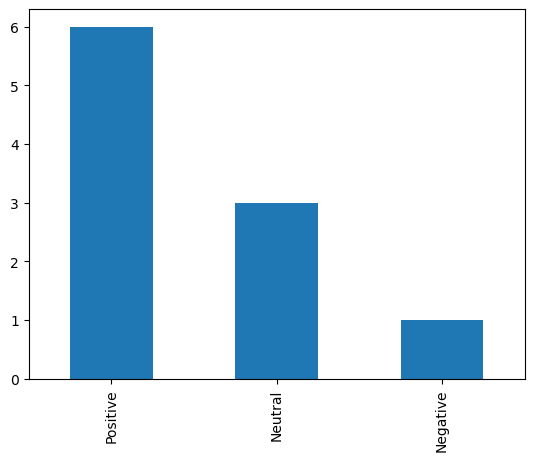

In [39]:
df['final_review'].value_counts().plot.bar()

In [40]:
!pip install openai

Defaulting to user installation because normal site-packages is not writeable


In [67]:
#https://www.datacamp.com/blog/an-introduction-to-pandas-ai